# Heart Disease - Model Training

Updated for the actual dataset format: text categorical columns need encoding,
target `num` (0-4) needs to be converted to binary, and `id`/`dataset` columns are dropped.

This notebook covers:
1. Data preprocessing (cleaning + encoding + using our shared `preprocessing.py`)
2. Classical ML models: Logistic Regression, Random Forest, XGBoost
3. Deep Learning: an Artificial Neural Network (ANN) built in Keras
4. Activation function comparison experiment (ReLU vs Leaky ReLU vs tanh vs ELU)
5. Final comparison table

In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from xgboost import XGBClassifier

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

from preprocessing import load_data, handle_missing_values, encode_categorical, scale_features

np.random.seed(42)
tf.random.set_seed(42)

In [2]:
df = load_data('../data/heart_disease_uci.csv')

# Drop columns not useful for prediction
df = df.drop(columns=['id', 'dataset'])

# Convert target to binary: 0 = no disease, 1 = disease present (any severity)
y = (df['num'] > 0).astype(int)
df_features = df.drop(columns=['num'])

print(df_features.shape, y.value_counts())

(920, 13) num
1    509
0    411
Name: count, dtype: int64


In [3]:
# Impute missing values (median for numeric, most frequent for categorical)
df_features = handle_missing_values(df_features)

# One-hot encode text categorical columns
cat_cols = df_features.select_dtypes(exclude=[np.number]).columns.tolist()
print('Categorical columns to encode:', cat_cols)

X = encode_categorical(df_features, cat_cols)
print(X.shape)
X.head()

Categorical columns to encode: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
(920, 18)


,age,trestbps,chol,thalch,oldpeak,ca,sex_Male,cp_atypical angina,cp_non-anginal,cp_typical angina,fbs_True,restecg_normal,restecg_st-t abnormality,exang_True,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
0,63.0,145.0,233.0,150.0,2.3,0.0,True,False,False,True,True,False,False,False,False,False,False,False
1,67.0,160.0,286.0,108.0,1.5,3.0,True,False,False,False,False,False,False,True,True,False,True,False
2,67.0,120.0,229.0,129.0,2.6,2.0,True,False,False,False,False,False,False,True,True,False,False,True
3,37.0,130.0,250.0,187.0,3.5,0.0,True,False,True,False,False,True,False,False,False,False,True,False
4,41.0,130.0,204.0,172.0,1.4,0.0,False,True,False,False,False,False,False,False,False,True,True,False


In [4]:
# Save the final column order/names - needed so the Streamlit app can
# build a matching input row at inference time (same approach as kidney notebook)
joblib.dump(X.columns.tolist(), '../models/heart_columns.pkl')

['../models/heart_columns.pkl']

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_train_scaled, X_test_scaled, scaler = scale_features(X_train, X_test, save_path='../models/heart_scaler.pkl')
print('Train shape:', X_train_scaled.shape, ' Test shape:', X_test_scaled.shape)

Train shape: (736, 18)  Test shape: (184, 18)


## Part 1: Classical ML Models

In [6]:
results = {}

def evaluate_model(name, model, X_test, y_test):
    preds = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else preds
    results[name] = {
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'F1': f1_score(y_test, preds),
        'ROC-AUC': roc_auc_score(y_test, proba)
    }
    print(f'--- {name} ---')
    for k, v in results[name].items():
        print(f'{k}: {v:.4f}')
    print()

In [7]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)
evaluate_model('Logistic Regression', log_reg, X_test_scaled, y_test)

--- Logistic Regression ---
Accuracy: 0.8424
Precision: 0.8411
Recall: 0.8824
F1: 0.8612
ROC-AUC: 0.9032



In [8]:
rf = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
rf.fit(X_train_scaled, y_train)
evaluate_model('Random Forest', rf, X_test_scaled, y_test)

--- Random Forest ---
Accuracy: 0.8478
Precision: 0.8304
Recall: 0.9118
F1: 0.8692
ROC-AUC: 0.9168



In [9]:
xgb = XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05, use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb.fit(X_train_scaled, y_train)
evaluate_model('XGBoost', xgb, X_test_scaled, y_test)

--- XGBoost ---
Accuracy: 0.8315
Precision: 0.8447
Recall: 0.8529
F1: 0.8488
ROC-AUC: 0.9103



C:\Users\harsh\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:200: UserWarning: [14:11:21] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


## Part 2: Deep Learning - Artificial Neural Network (ANN)

We build a simple feedforward network and run a controlled experiment comparing different **activation functions** in the hidden layers.

In [10]:
def build_ann(input_dim, hidden_activation='relu', output_activation='sigmoid'):
    model = Sequential([
        Dense(32, activation=hidden_activation, input_shape=(input_dim,)),
        Dense(16, activation=hidden_activation),
        Dense(8, activation=hidden_activation),
        Dense(1, activation=output_activation)
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

In [11]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

ann_relu = build_ann(X_train_scaled.shape[1], hidden_activation='relu')
history_relu = ann_relu.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=0
)

loss, acc = ann_relu.evaluate(X_test_scaled, y_test, verbose=0)
print(f'ANN (ReLU) Test Accuracy: {acc:.4f}')

C:\Users\harsh\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


ANN (ReLU) Test Accuracy: 0.8424


In [12]:
preds_proba = ann_relu.predict(X_test_scaled).flatten()
preds = (preds_proba > 0.5).astype(int)

results['ANN (ReLU)'] = {
    'Accuracy': accuracy_score(y_test, preds),
    'Precision': precision_score(y_test, preds),
    'Recall': recall_score(y_test, preds),
    'F1': f1_score(y_test, preds),
    'ROC-AUC': roc_auc_score(y_test, preds_proba)
}
print(results['ANN (ReLU)'])

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
{'Accuracy': 0.842391304347826, 'Precision': 0.8348623853211009, 'Recall': 0.8921568627450981, 'F1': 0.8625592417061612, 'ROC-AUC': 0.9195361071257772}


## Part 3: Activation Function Comparison Experiment

In [13]:
activation_functions = ['relu', 'tanh', 'sigmoid', 'elu']
activation_histories = {}

for act in activation_functions:
    model = build_ann(X_train_scaled.shape[1], hidden_activation=act)
    hist = model.fit(
        X_train_scaled, y_train,
        validation_split=0.2,
        epochs=100,
        batch_size=16,
        callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)],
        verbose=0
    )
    activation_histories[act] = hist
    loss, acc = model.evaluate(X_test_scaled, y_test, verbose=0)
    print(f'{act}: Test Accuracy = {acc:.4f}, Epochs trained = {len(hist.history["loss"])}')

C:\Users\harsh\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


relu: Test Accuracy = 0.8478, Epochs trained = 18
tanh: Test Accuracy = 0.8587, Epochs trained = 19
sigmoid: Test Accuracy = 0.8478, Epochs trained = 93
elu: Test Accuracy = 0.8478, Epochs trained = 22


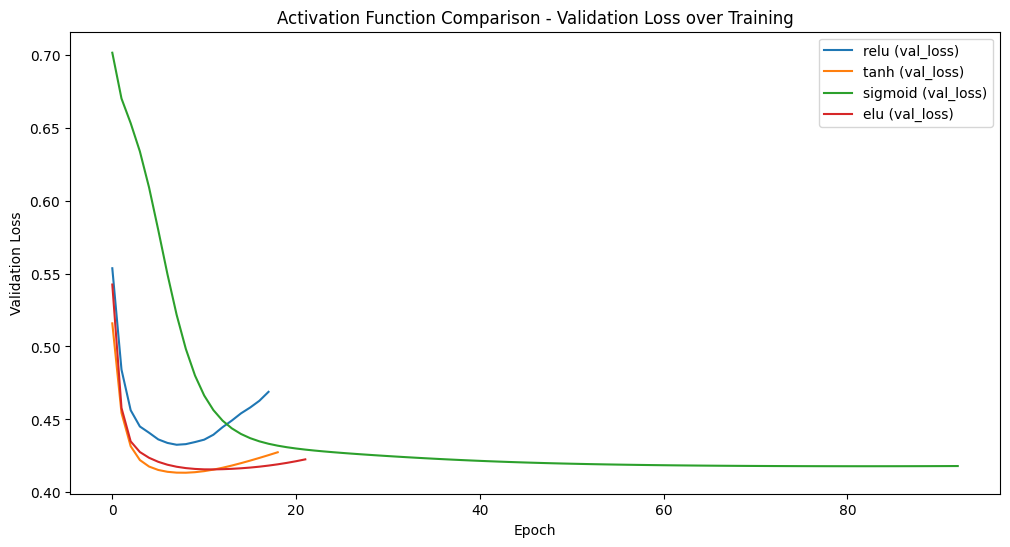

In [14]:
plt.figure(figsize=(12, 6))
for act, hist in activation_histories.items():
    plt.plot(hist.history['val_loss'], label=f'{act} (val_loss)')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.title('Activation Function Comparison - Validation Loss over Training')
plt.legend()
plt.show()

## Part 4: Final Comparison Table

In [15]:
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('F1', ascending=False)
results_df

,Accuracy,Precision,Recall,F1,ROC-AUC
Random Forest,0.847826,0.830357,0.911765,0.869159,0.916786
ANN (ReLU),0.842391,0.834862,0.892157,0.862559,0.919536
Logistic Regression,0.842391,0.841121,0.882353,0.861244,0.903156
XGBoost,0.831522,0.844660,0.852941,0.848780,0.910330


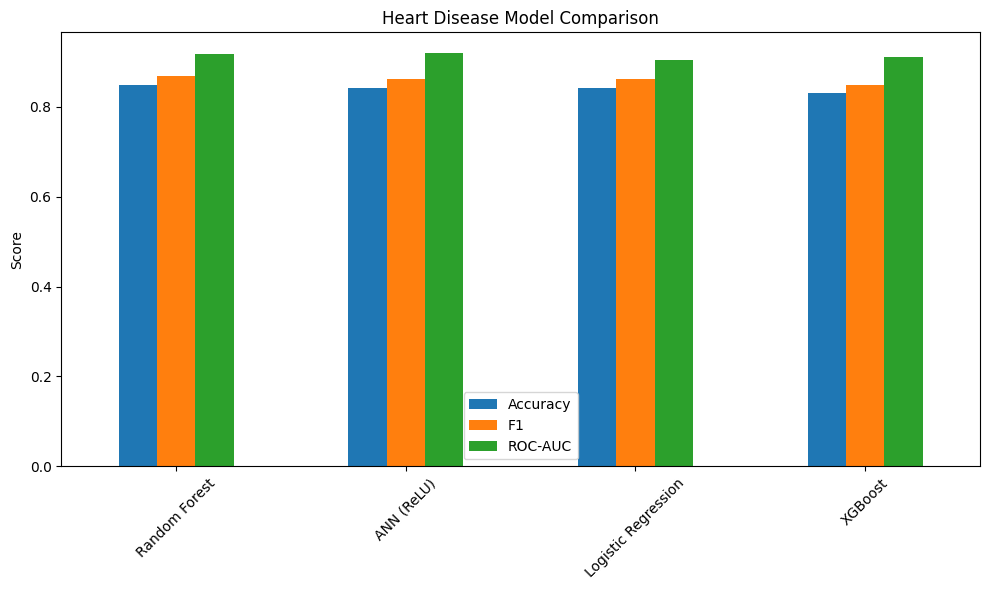

In [16]:
results_df[['Accuracy', 'F1', 'ROC-AUC']].plot(kind='bar', figsize=(10, 6))
plt.title('Heart Disease Model Comparison')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Save Best Model

In [17]:
ann_relu.save('../models/heart_model.h5')
print('Saved: ../models/heart_model.h5')

Saved: ../models/heart_model.h5


## Key Takeaways (fill in after running)

- Best performing model overall: ...
- Which activation function converged fastest / gave best validation loss: ...
- Did the ANN outperform classical ML here, or was classical ML competitive: ...